Loaded dataset subset:
Nodes: 17572
Edges: 26057
Largest connected component size: 11183
--------------------------------------------------
Input size: 100
Case: Best case
Source: 12800
Target: 12799
Path length: 1
Dijkstra average time: 0.02194000262534246 ms
Bellman-Ford average time: 0.5014199996367097 ms
--------------------------------------------------
Input size: 100
Case: Average case
Source: 37591
Target: 12890
Path length: 7
Dijkstra average time: 0.14550000050803646 ms
Bellman-Ford average time: 0.5457600011141039 ms
--------------------------------------------------
Input size: 100
Case: Worst case
Source: 12828
Target: 12909
Path length: 16
Dijkstra average time: 0.3145000009681098 ms
Bellman-Ford average time: 0.4992999995010905 ms
--------------------------------------------------
Input size: 500
Case: Best case
Source: 12392
Target: 7449
Path length: 1
Dijkstra average time: 0.022739997075404972 ms
Bellman-Ford average time: 2.892680000513792 ms
------------------------

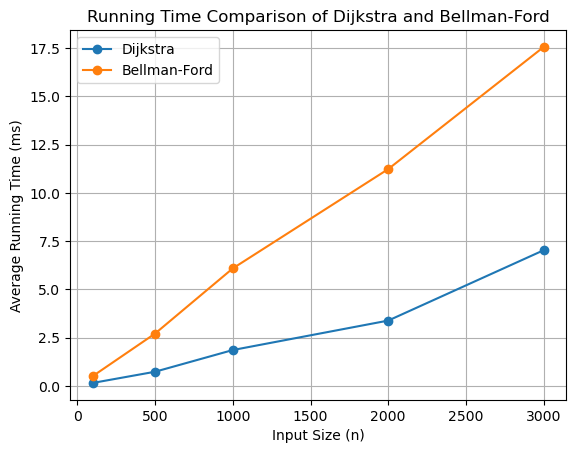

In [2]:
import networkx as nx
import time
import random
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Experiment settings
# -------------------------------------------------------
DATASET_FILE = "roadNet-CA.txt"
EDGE_LIMIT = 50000
INPUT_SIZES = [100, 500, 1000, 2000, 3000]
REPEATS = 5
RANDOM_SEED = 42

random.seed(RANDOM_SEED)

# -------------------------------------------------------
# Load roadNet-CA dataset subset
# -------------------------------------------------------
edges = []

with open(DATASET_FILE, "r") as file:
    for line in file:
        if line.startswith("#"):
            continue

        u, v = map(int, line.strip().split())
        edges.append((u, v))

        # Use a subset because the full dataset is very large
        if len(edges) >= EDGE_LIMIT:
            break

# -------------------------------------------------------
# Build an undirected graph
# Each edge weight is set to 1 because the dataset is unweighted
# -------------------------------------------------------
G = nx.Graph()
G.add_edges_from(edges)

for u, v in G.edges():
    G[u][v]["weight"] = 1

print("Loaded dataset subset:")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# -------------------------------------------------------
# Use the largest connected component to ensure valid paths
# -------------------------------------------------------
largest_cc = max(nx.connected_components(G), key=len)
main_graph = G.subgraph(largest_cc).copy()

print("Largest connected component size:", main_graph.number_of_nodes())
print("-" * 50)

# -------------------------------------------------------
# Create a connected subgraph of size n
# -------------------------------------------------------
def create_connected_subgraph(graph, n):
    start_node = random.choice(list(graph.nodes()))
    selected_nodes = {start_node}
    queue = [start_node]

    while queue and len(selected_nodes) < n:
        current = queue.pop(0)
        neighbors = list(graph.neighbors(current))
        random.shuffle(neighbors)

        for neighbor in neighbors:
            if neighbor not in selected_nodes:
                selected_nodes.add(neighbor)
                queue.append(neighbor)

                if len(selected_nodes) == n:
                    break

    return graph.subgraph(selected_nodes).copy()

# -------------------------------------------------------
# Select source and target nodes based on case type
# -------------------------------------------------------
def select_input_pair(graph, case_type):
    nodes = list(graph.nodes())

    if case_type == "Best case":
        # Best case: directly connected nodes
        u, v = list(graph.edges())[0]
        return u, v

    elif case_type == "Average case":
        # Average case: random pair from the same connected subgraph
        source = random.choice(nodes)
        target = random.choice(nodes)

        while source == target:
            target = random.choice(nodes)

        return source, target

    elif case_type == "Worst case":
        # Worst case approximation: choose two far-apart nodes
        start = random.choice(nodes)

        distances_from_start = nx.single_source_shortest_path_length(graph, start)
        farthest_node = max(distances_from_start, key=distances_from_start.get)

        distances_from_farthest = nx.single_source_shortest_path_length(graph, farthest_node)
        target = max(distances_from_farthest, key=distances_from_farthest.get)

        return farthest_node, target

# -------------------------------------------------------
# Run Dijkstra Algorithm and measure execution time
# -------------------------------------------------------
def run_dijkstra(graph, source, target):
    start = time.perf_counter()

    path = nx.dijkstra_path(graph, source, target, weight="weight")

    end = time.perf_counter()
    execution_time = (end - start) * 1000

    return execution_time, len(path) - 1

# -------------------------------------------------------
# Run Bellman-Ford Algorithm and measure execution time
# -------------------------------------------------------
def run_bellman_ford(graph, source, target):
    start = time.perf_counter()

    path = nx.bellman_ford_path(graph, source, target, weight="weight")

    end = time.perf_counter()
    execution_time = (end - start) * 1000

    return execution_time, len(path) - 1

# -------------------------------------------------------
# Calculate average running time
# -------------------------------------------------------
def average_time(algorithm_function, graph, source, target, repeats=5):
    times = []
    path_length = 0

    for _ in range(repeats):
        execution_time, path_length = algorithm_function(graph, source, target)
        times.append(execution_time)

    average_execution_time = sum(times) / len(times)

    return average_execution_time, path_length

# -------------------------------------------------------
# Run experiments
# -------------------------------------------------------
case_types = ["Best case", "Average case", "Worst case"]
results = []

for n in INPUT_SIZES:
    if n > main_graph.number_of_nodes():
        print("Input size", n, "is larger than the available connected component.")
        continue

    subgraph_n = create_connected_subgraph(main_graph, n)

    for case_type in case_types:
        source, target = select_input_pair(subgraph_n, case_type)

        dijkstra_time, dijkstra_path_length = average_time(
            run_dijkstra,
            subgraph_n,
            source,
            target,
            REPEATS
        )

        bellman_time, bellman_path_length = average_time(
            run_bellman_ford,
            subgraph_n,
            source,
            target,
            REPEATS
        )

        results.append({
            "Input Size": n,
            "Case": case_type,
            "Source": source,
            "Target": target,
            "Path Length": dijkstra_path_length,
            "Dijkstra Time": dijkstra_time,
            "Bellman-Ford Time": bellman_time
        })

        print("Input size:", n)
        print("Case:", case_type)
        print("Source:", source)
        print("Target:", target)
        print("Path length:", dijkstra_path_length)
        print("Dijkstra average time:", dijkstra_time, "ms")
        print("Bellman-Ford average time:", bellman_time, "ms")
        print("-" * 50)

# -------------------------------------------------------
# Print results in table format
# -------------------------------------------------------
print("\nFinal Results:")
print("Input Size | Case | Path Length | Dijkstra Time (ms) | Bellman-Ford Time (ms)")
print("-" * 85)

for result in results:
    print(
        result["Input Size"], "|",
        result["Case"], "|",
        result["Path Length"], "|",
        round(result["Dijkstra Time"], 4), "|",
        round(result["Bellman-Ford Time"], 4)
    )

# -------------------------------------------------------
# Plot average running time by input size
# -------------------------------------------------------
average_by_size = {}

for n in INPUT_SIZES:
    dijkstra_times = [
        result["Dijkstra Time"]
        for result in results
        if result["Input Size"] == n
    ]

    bellman_times = [
        result["Bellman-Ford Time"]
        for result in results
        if result["Input Size"] == n
    ]

    if dijkstra_times and bellman_times:
        average_by_size[n] = {
            "Dijkstra": sum(dijkstra_times) / len(dijkstra_times),
            "Bellman-Ford": sum(bellman_times) / len(bellman_times)
        }

sizes = list(average_by_size.keys())
dijkstra_plot_times = [average_by_size[n]["Dijkstra"] for n in sizes]
bellman_plot_times = [average_by_size[n]["Bellman-Ford"] for n in sizes]

plt.plot(sizes, dijkstra_plot_times, marker="o", label="Dijkstra")
plt.plot(sizes, bellman_plot_times, marker="o", label="Bellman-Ford")

plt.xlabel("Input Size (n)")
plt.ylabel("Average Running Time (ms)")
plt.title("Running Time Comparison of Dijkstra and Bellman-Ford")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# -------------------------------------------------------
# Print detailed results table
# -------------------------------------------------------
print("\nDetailed Results Table:")
print("Input Size | Case Type | Path Length | Dijkstra Avg Time (ms) | Bellman-Ford Avg Time (ms) | Faster Algorithm")
print("-" * 120)

for result in results:
    faster = "Dijkstra" if result["Dijkstra Time"] < result["Bellman-Ford Time"] else "Bellman-Ford"

    print(
        result["Input Size"], "|",
        result["Case"], "|",
        result["Path Length"], "|",
        round(result["Dijkstra Time"], 4), "|",
        round(result["Bellman-Ford Time"], 4), "|",
        faster
    )


# -------------------------------------------------------
# Print summary results table by input size
# -------------------------------------------------------
print("\nSummary Results Table:")
print("Input Size | Dijkstra Avg Time (ms) | Bellman-Ford Avg Time (ms) | Faster Algorithm")
print("-" * 90)

for n in INPUT_SIZES:
    dijkstra_times = [
        result["Dijkstra Time"]
        for result in results
        if result["Input Size"] == n
    ]

    bellman_times = [
        result["Bellman-Ford Time"]
        for result in results
        if result["Input Size"] == n
    ]

    if dijkstra_times and bellman_times:
        d_avg = sum(dijkstra_times) / len(dijkstra_times)
        b_avg = sum(bellman_times) / len(bellman_times)

        faster = "Dijkstra" if d_avg < b_avg else "Bellman-Ford"

        print(
            n, "|",
            round(d_avg, 4), "|",
            round(b_avg, 4), "|",
            faster
        )


Detailed Results Table:
Input Size | Case Type | Path Length | Dijkstra Avg Time (ms) | Bellman-Ford Avg Time (ms) | Faster Algorithm
------------------------------------------------------------------------------------------------------------------------
100 | Best case | 1 | 0.4015 | 0.9851 | Dijkstra
100 | Average case | 7 | 0.1667 | 0.5089 | Dijkstra
100 | Worst case | 16 | 0.3731 | 0.5738 | Dijkstra
500 | Best case | 1 | 0.0228 | 2.8988 | Dijkstra
500 | Average case | 8 | 0.2985 | 2.7056 | Dijkstra
500 | Worst case | 25 | 2.2299 | 2.9446 | Dijkstra
1000 | Best case | 1 | 0.0342 | 7.3705 | Dijkstra
1000 | Average case | 20 | 2.0562 | 6.6478 | Dijkstra
1000 | Worst case | 36 | 4.8316 | 6.0201 | Dijkstra
2000 | Best case | 1 | 0.0322 | 16.7597 | Dijkstra
2000 | Average case | 15 | 1.7512 | 14.8192 | Dijkstra
2000 | Worst case | 37 | 11.2864 | 12.9794 | Dijkstra
3000 | Best case | 1 | 0.0364 | 23.4985 | Dijkstra
3000 | Average case | 32 | 10.5716 | 23.8998 | Dijkstra
3000 | Worst case

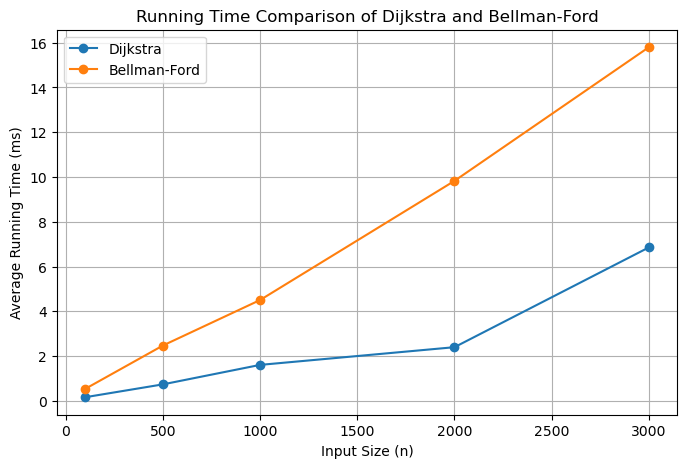

In [5]:
import matplotlib.pyplot as plt

# Final average results from Table 7
sizes = [100, 500, 1000, 2000, 3000]
dijkstra_times = [0.1618, 0.7367, 1.6066, 2.3973, 6.8549]
bellman_times = [0.5348, 2.4724, 4.5053, 9.8279, 15.7993]

plt.figure(figsize=(8, 5))
plt.plot(sizes, dijkstra_times, marker="o", label="Dijkstra")
plt.plot(sizes, bellman_times, marker="o", label="Bellman-Ford")

plt.xlabel("Input Size (n)")
plt.ylabel("Average Running Time (ms)")
plt.title("Running Time Comparison of Dijkstra and Bellman-Ford")
plt.legend()
plt.grid(True)
plt.savefig("running_time_comparison.png", dpi=300, bbox_inches="tight")
plt.show()